# Vartalaap Banking: Application Pipeline Analytics
**Goal:** clean raw scheme-application data, measure branch quality and approval turnaround, flag anomalies, and export tables for a Tableau dashboard.

**Data:** synthetic, generated by `generate_data.py` to mirror the Vartalaap schema (APY, PMJJBY, PMSBY, KVP, PMMY). Some patterns were planted to validate the pipeline (see `docs/planted_patterns.md`), so the findings below demonstrate the *method*, not real-world results.

**Extract date:** 2026-10-01.

Sections: 1 Profile, 2 Clean (with decision log), 3 Audit against the answer key, 4 Analysis, 5 SQL layer, 6 Exports, 7 Findings.

In [1]:
import json, re, sqlite3
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
RAW, CLEAN, CHARTS = Path("../data/raw"), Path("../data/clean"), Path("../charts")
SNAPSHOT = pd.Timestamp("2026-10-01")
for p in (CLEAN, CHARTS): p.mkdir(exist_ok=True)

apps = pd.read_csv(RAW / "applications_raw.csv", dtype=str, keep_default_na=False, na_values=[""])
users = pd.read_csv(RAW / "users.csv", dtype={"username": str})
print("applications:", apps.shape, "| users:", users.shape)

Matplotlib is building the font cache; this may take a moment.


applications: (12240, 17) | users: (27, 7)


## 1. Profile the raw data

In [2]:
profile = pd.DataFrame({"null_%": (apps.isna().mean() * 100).round(1), "distinct": apps.nunique()})
display(profile)
print("exact duplicate rows:", apps.duplicated().sum())
print("duplicate application_ids:", apps.application_id.duplicated().sum())
print("\nstatus values:\n", apps.status.value_counts(dropna=False).to_string())
print("\nscheme counts:\n", apps.scheme.value_counts().to_string())

,null_%,distinct
application_id,0.0,12143
scheme,0.0,5
full_name,0.0,1958
age,1.5,88
aadhaar_last4,0.0,7027
submitted_by,0.0,21
submission_date,0.0,958
status,0.0,14
approver_remark,58.8,79
decided_date,3.1,903


exact duplicate rows: 97
duplicate application_ids: 97

status values:
 status
Approved      9341
Rejected      1362
approved       394
Pending        339
APPROVED       318
 Approved      307
rejected        46
 Rejected       42
REJECTED        41
pending         14
Aproved         12
PENDING         12
 Pending        10
Rejeted          2

scheme counts:
 scheme
APY       3668
PMJJBY    2696
PMSBY     2685
PMMY      1720
KVP       1471


## 2. Clean, with a decision log
Every change is recorded in `cleaning_log`. Rule of thumb: **fix what is unambiguous, flag what is not, and never silently delete.**

In [3]:
cleaning_log = []
def log(step, issue, action, n):
    cleaning_log.append(dict(step=step, issue=issue, action=action, rows_affected=int(n)))
    print(f"[{step}] {issue} -> {action}: {int(n)} rows")

df = apps.copy()

# 1. exact duplicates (double-submit): identical in every column, so safe to drop
n = df.duplicated().sum(); df = df.drop_duplicates().reset_index(drop=True)
log("dedupe", "exact duplicate rows", "dropped", n)
assert df.application_id.is_unique

# 2. names
clean_name = df.full_name.str.strip().str.replace(r"\s+", " ", regex=True).str.title()
log("text", "name casing/spacing noise", "trimmed, collapsed spaces, title-cased", (clean_name != df.full_name).sum())
df["full_name"] = clean_name

# 3. status
def norm_status(s):
    if pd.isna(s): return np.nan
    t = s.strip().lower()
    return "Approved" if t.startswith("ap") else "Rejected" if t.startswith("rej") else "Pending" if t.startswith("pen") else np.nan
status_clean = df.status.map(norm_status)
log("status", "case/space/typo variants", "mapped to Approved/Rejected/Pending", (status_clean != df.status).sum())
log("status", "unmappable status", "left null and excluded from rate calculations", status_clean.isna().sum())
df["status"] = status_clean

# 4. dates (three formats seen in profiling)
def parse_date(s):
    if pd.isna(s): return pd.NaT
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%b-%Y"):
        try: return pd.to_datetime(s.strip(), format=fmt)
        except ValueError: pass
    return pd.NaT
sub_raw, dec_raw = df.submission_date, df.decided_date
df["submission_date"] = sub_raw.map(parse_date); df["decided_date"] = dec_raw.map(parse_date)
log("dates", "unparseable submission_date", "set to NaT, flagged", (sub_raw.notna() & df.submission_date.isna()).sum())
log("dates", "unparseable decided_date", "set to NaT", (dec_raw.notna() & df.decided_date.isna()).sum())
df["flag_future_submission"] = df.submission_date > SNAPSHOT
log("dates", "submission_date after extract date", "flagged, excluded from time analysis", df.flag_future_submission.sum())
df["flag_decided_before_submitted"] = (df.decided_date < df.submission_date) & ~df.flag_future_submission   # future-dated rows are handled above
log("dates", "decided_date before submission_date", "decided_date nulled, flagged", df.flag_decided_before_submitted.sum())
df.loc[df.flag_decided_before_submitted, "decided_date"] = pd.NaT

# 5. amounts
def parse_amount(s):
    if pd.isna(s): return np.nan
    t = re.sub(r"[^\d.]", "", re.sub(r"(?i)rs\.?", "", s))
    return float(t) if t else np.nan
df["amount"] = df.amount_raw.map(parse_amount)
log("amount", "currency symbols, commas, decimals", "parsed to numeric", (df.amount_raw.str.contains(r"[^\d]", na=False)).sum())

# 6. age
df["age"] = df.age.map(lambda s: np.nan if pd.isna(s) else (float(m.group()) if (m := re.search(r"-?\d+", s)) else np.nan))
df["flag_age_invalid"] = df.age.notna() & ~df.age.between(18, 100)
log("age", "impossible age (<18 or >100)", "set to NaN, flagged", df.flag_age_invalid.sum())
df.loc[df.flag_age_invalid, "age"] = np.nan
log("age", "missing age", "left null", df.age.isna().sum())
MAX_AGE = {"APY": 40, "PMJJBY": 50, "PMSBY": 70, "KVP": 100, "PMMY": 65}
df["flag_age_ineligible"] = df.age > df.scheme.map(MAX_AGE)
log("age", "age above scheme maximum", "flagged (real eligibility violation, kept)", df.flag_age_ineligible.sum())

# 7. document flags
YES, NO = {"yes", "y", "1", "true"}, {"no", "n", "0", "false"}
for c in ("aadhaar_doc", "pan_doc", "cheque_doc"):
    df[c] = df[c].map(lambda s: np.nan if pd.isna(s) else True if s.strip().lower() in YES else False if s.strip().lower() in NO else np.nan)
df["any_doc_missing"] = (df[["aadhaar_doc", "pan_doc", "cheque_doc"]] == False).any(axis=1)
log("docs", "Yes/Y/yes/1 and No/N/no/0 variants", "mapped to boolean", len(df) * 3)

# 8. branch via users (same rule as the SQL: first non-null-branch row per username by user_id)
u = users[users.branch.notna() & users.username.notna()].sort_values("user_id").drop_duplicates("username", keep="first")
df["branch"] = df.submitted_by.map(u.set_index("username").branch)
df["region"] = df.submitted_by.map(u.set_index("username").region)
orphans = df.branch.isna()
df["branch"] = df.branch.fillna("Unknown"); df["region"] = df.region.fillna("Unknown")
log("join", "submitted_by with no matching user", "branch set to 'Unknown', excluded from branch analysis", orphans.sum())
log("join", "usernames duplicated in users", "first non-null-branch row wins", users.username.duplicated().sum())

# 9. near-duplicate resubmissions (same applicant, same scheme, within 14 days): flag, never delete
df = df.sort_values(["scheme", "full_name", "aadhaar_last4", "submission_date"]).reset_index(drop=True)
prev = df.groupby(["scheme", "full_name", "aadhaar_last4"])["submission_date"].shift()
df["is_resubmission"] = (df.submission_date - prev).dt.days.between(0, 14)
log("dedupe", "same applicant re-filed within 14 days", "flagged as resubmission", df.is_resubmission.sum())

# 10. rejection reason categories from free text
RULES = [("duplicate_application", r"duplicat"), ("apy_contribution_mismatch", r"contri|contib"), ("age_not_eligible", r"\bage\b"),
         ("missing_documents", r"a{1,2}dh?a{1,2}r|\bpan\b|cheque|document|docs|kyc"), ("other", r"signature|mobile|bank account")]
def categorize(r):
    if r.status != "Rejected": return np.nan
    if pd.isna(r.approver_remark): return "no_remark"
    t = r.approver_remark.strip().lower()
    for cat, pat in RULES:
        if re.search(pat, t): return cat
    return "uncategorized"
df["rejection_reason"] = df.apply(categorize, axis=1)
log("text", "free-text rejection remarks", "keyword rules -> 5 categories", df.rejection_reason.notna().sum())

# 11. APY compliance, recomputed from the contribution table (bracket lookup)
APY = {18: [42, 84, 126, 168, 210], 20: [50, 100, 150, 198, 248], 25: [76, 151, 226, 301, 376],
       30: [116, 231, 347, 462, 577], 35: [181, 362, 543, 722, 902], 40: [291, 582, 873, 1154, 1454]}
def apy_required(r):
    if r.scheme != "APY" or pd.isna(r.age): return np.nan
    tier = re.sub(r"\D", "", r.pension_tier or "")
    if not tier or int(tier) not in (1000, 2000, 3000, 4000, 5000): return np.nan
    bracket = max(a for a in APY if a <= max(r.age, 18))
    return APY[bracket][int(tier) // 1000 - 1]
df["apy_required"] = df.apply(apy_required, axis=1)
df["apy_compliance"] = np.where(df.apy_required.isna() | df.amount.isna(), None,
                                np.where(df.amount >= df.apy_required, "Compliant", "Non-Compliant"))
df["apy_compliance"] = df.apy_compliance.where(df.apy_compliance.notna(), np.nan)

# amount sanity rules per scheme (flag, never overwrite)
def amount_suspect(r):
    a, s = r.amount, r.scheme
    if pd.isna(a): return True
    if s == "PMJJBY": return a != 436
    if s == "PMSBY": return a != 20
    if s == "APY": return a > 1500 or (pd.notna(r.apy_required) and a > 2 * r.apy_required)
    if s == "KVP": return a < 1000 or a > 500000
    lo, hi = {"Shishu": (0, 50000), "Kishore": (50000, 500000), "Tarun": (500000, 1000000)}.get(r.business_type, (0, 1e7))
    return not (lo <= a <= hi)
df["flag_amount_suspect"] = df.apply(amount_suspect, axis=1)
log("amount", "amount outside scheme rule (PMJJBY != 436, PMSBY != 20, APY > 2x required, KVP/PMMY out of range)", "flagged, not changed", df.flag_amount_suspect.sum())

# 12. derived measures
done = df.status.isin(["Approved", "Rejected"])
df["turnaround_days"] = np.where(done, (df.decided_date - df.submission_date).dt.days, np.nan)
log("derived", "Approved/Rejected rows with no usable decided_date", "excluded from turnaround only", (done & df.decided_date.isna()).sum())
df["pending_age_days"] = np.where(df.status == "Pending", (SNAPSHOT - df.submission_date).dt.days, np.nan)
df["is_stale_pending"] = df.pending_age_days > 30
df["month"] = df.submission_date.dt.to_period("M").astype(str).replace("NaT", np.nan)

# analysis population: valid submission date, not in the future
ok = df.submission_date.notna() & ~df.flag_future_submission
log("scope", "rows with missing or future submission_date", "excluded from time-based analysis", (~ok).sum())
a = df[ok].copy()
print("\nclean rows:", len(df), "| analysis rows:", len(a))
pd.DataFrame(cleaning_log).to_csv(CLEAN / "cleaning_log.csv", index=False)

[dedupe] exact duplicate rows -> dropped: 97 rows
[text] name casing/spacing noise -> trimmed, collapsed spaces, title-cased: 1845 rows
[status] case/space/typo variants -> mapped to Approved/Rejected/Pending: 1187 rows
[status] unmappable status -> left null and excluded from rate calculations: 0 rows


[dates] unparseable submission_date -> set to NaT, flagged: 36 rows
[dates] unparseable decided_date -> set to NaT: 0 rows
[dates] submission_date after extract date -> flagged, excluded from time analysis: 24 rows
[dates] decided_date before submission_date -> decided_date nulled, flagged: 58 rows
[amount] currency symbols, commas, decimals -> parsed to numeric: 4837 rows
[age] impossible age (<18 or >100) -> set to NaN, flagged: 97 rows
[age] missing age -> left null: 279 rows
[age] age above scheme maximum -> flagged (real eligibility violation, kept): 117 rows
[docs] Yes/Y/yes/1 and No/N/no/0 variants -> mapped to boolean: 36429 rows
[join] submitted_by with no matching user -> branch set to 'Unknown', excluded from branch analysis: 64 rows
[join] usernames duplicated in users -> first non-null-branch row wins: 1 rows
[dedupe] same applicant re-filed within 14 days -> flagged as resubmission: 143 rows
[text] free-text rejection remarks -> keyword rules -> 5 categories: 1484 rows


[amount] amount outside scheme rule (PMJJBY != 436, PMSBY != 20, APY > 2x required, KVP/PMMY out of range) -> flagged, not changed: 42 rows
[derived] Approved/Rejected rows with no usable decided_date -> excluded from turnaround only: 58 rows
[scope] rows with missing or future submission_date -> excluded from time-based analysis: 60 rows

clean rows: 12143 | analysis rows: 12083


## 3. Audit the cleaning against the answer key
In real work you would not have ground truth. Here we do, so we can check that each cleaning rule actually recovered what was injected.

In [4]:
inj = json.loads(Path("../data/ground_truth/messiness_log.json").read_text())
truth = pd.read_csv("../data/ground_truth/applications_truth.csv")
audit = pd.DataFrame([
    ("exact duplicates dropped", inj["exact_duplicate_rows_added"], len(apps) - len(df)),
    ("decided before submitted", inj["decided_before_submitted"], int(df.flag_decided_before_submitted.sum())),
    ("future submission dates", inj["submission_date_in_future"], int(df.flag_future_submission.sum())),
    ("orphan submitted_by", inj["orphan_submitted_by"], int(orphans.sum())),
], columns=["check", "injected", "found"])
display(audit)

# amount typos: how good is the rule-based detector?
chk = df.merge(truth[["application_id", "amount"]].rename(columns={"amount": "true_amount"}), on="application_id")
injected_mask = chk.amount != chk.true_amount
caught = chk.flag_amount_suspect & injected_mask
print(f"Amount typos: {injected_mask.sum()} injected | rule flagged {chk.flag_amount_suspect.sum()} rows | "
      f"recall {caught.sum() / injected_mask.sum():.0%} | precision {caught.sum() / chk.flag_amount_suspect.sum():.0%}")
print("Misses are x10 typos that still look plausible for the scheme (e.g. a small KVP deposit); "
      "they need a reference value or the source document to catch.")

m = df.merge(truth[["application_id", "true_cause"]], on="application_id", how="left")
m = m[m.status == "Rejected"]
acc = (m.rejection_reason == m.true_cause).mean()
print(f"Rejection-reason keyword rules agree with the true cause on {acc:.1%} of rejected rows")
print(pd.crosstab(m.true_cause.fillna("none"), m.rejection_reason).to_string())

,check,injected,found
0,exact duplicates dropped,97,97
1,decided before submitted,58,58
2,future submission dates,24,24
3,orphan submitted_by,64,64


Amount typos: 48 injected | rule flagged 42 rows | recall 88% | precision 100%
Misses are x10 typos that still look plausible for the scheme (e.g. a small KVP deposit); they need a reference value or the source document to catch.
Rejection-reason keyword rules agree with the true cause on 100.0% of rejected rows
rejection_reason           age_not_eligible  apy_contribution_mismatch  duplicate_application  missing_documents  other
true_cause                                                                                                             
age_not_eligible                        109                          0                      0                  0      0
apy_contribution_mismatch                 0                        202                      0                  0      0
duplicate_application                     0                          0                    143                  0      0
missing_documents                         0                          0                

## 4. Analysis

### 4.1 Volume is not quality: branch scorecard

In [5]:
br = a[(a.branch != "Unknown")]
sc = br.groupby("branch").agg(region=("region", "first"), total=("application_id", "size"),
        approved=("status", lambda s: (s == "Approved").sum()), rejected=("status", lambda s: (s == "Rejected").sum()),
        pending=("status", lambda s: (s == "Pending").sum()))
sc["decided"] = sc.approved + sc.rejected
sc["approval_rate"] = sc.approved / sc.decided
p0 = sc.rejected.sum() / sc.decided.sum()                       # network-wide rejection rate
sc["rejection_rate"] = 1 - sc.approval_rate
sc["z_score"] = (sc.rejection_rate - p0) / np.sqrt(p0 * (1 - p0) / sc.decided)
sc["anomaly"] = sc.z_score > 3
sc["volume_rank"] = sc.total.rank(ascending=False, method="min").astype(int)
sc["quality_rank"] = sc.approval_rate.rank(ascending=False, method="min").astype(int)
sc = sc.sort_values("volume_rank")
print(f"Network rejection rate: {p0:.1%}")
display(sc[["region", "total", "approval_rate", "rejection_rate", "z_score", "anomaly", "volume_rank", "quality_rank"]].round(3))

Network rejection rate: 12.6%


,region,total,approval_rate,rejection_rate,z_score,anomaly,volume_rank,quality_rank
branch,,,,,,,,
Jaipur MI Road,Jaipur Region,1323,0.798,0.202,8.234,True,1,19
Meerut City,Meerut Region,883,0.911,0.089,-3.283,False,2,2
Delhi Karol Bagh,Delhi Region,784,0.885,0.115,-0.894,False,3,14
Noida Sector 18,NCR East Region,775,0.905,0.095,-2.593,False,4,3
Jaipur Vaishali Nagar,Jaipur Region,739,0.904,0.096,-2.448,False,5,4
Delhi Lajpat Nagar,Delhi Region,692,0.896,0.104,-1.642,False,6,8
Ghaziabad Nehru Nagar,NCR East Region,648,0.897,0.103,-1.793,False,7,7
Jaipur Mansarovar,Jaipur Region,638,0.870,0.130,0.290,False,8,17
Hapur,Meerut Region,579,0.889,0.111,-1.076,False,9,12


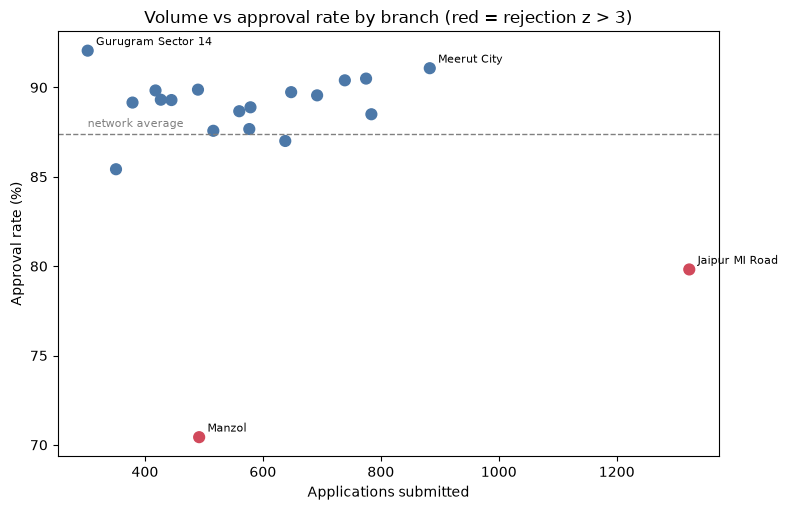

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.scatter(sc.total, sc.approval_rate * 100, s=60, c=np.where(sc.anomaly, "#d1495b", "#4c78a8"))
for b, r in sc.iterrows():
    if r.anomaly or r.volume_rank <= 2 or r.quality_rank <= 1: ax.annotate(b, (r.total, r.approval_rate * 100), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.axhline((1 - p0) * 100, ls="--", c="grey", lw=1); ax.text(sc.total.min(), (1 - p0) * 100 + 0.4, "network average", fontsize=8, color="grey")
ax.set_xlabel("Applications submitted"); ax.set_ylabel("Approval rate (%)"); ax.set_title("Volume vs approval rate by branch (red = rejection z > 3)")
plt.tight_layout(); plt.savefig(CHARTS / "volume_vs_approval.png", dpi=150); plt.show()

### 4.2 Why are anomalous branches rejected?

rejection_reason,age_not_eligible,apy_contribution_mismatch,duplicate_application,missing_documents,other
branch,,,,,
Jaipur MI Road,7.2,7.6,6.8,66.9,11.4
Manzol,3.5,6.9,0.7,83.3,5.6
Mawana,6.0,10.0,12.0,48.0,24.0
Jaipur Mansarovar,7.3,17.1,7.3,43.9,24.4


Network-wide mix (%):
rejection_reason
missing_documents            49.9
other                        19.6
apy_contribution_mismatch    13.4
duplicate_application         9.7
age_not_eligible              7.4


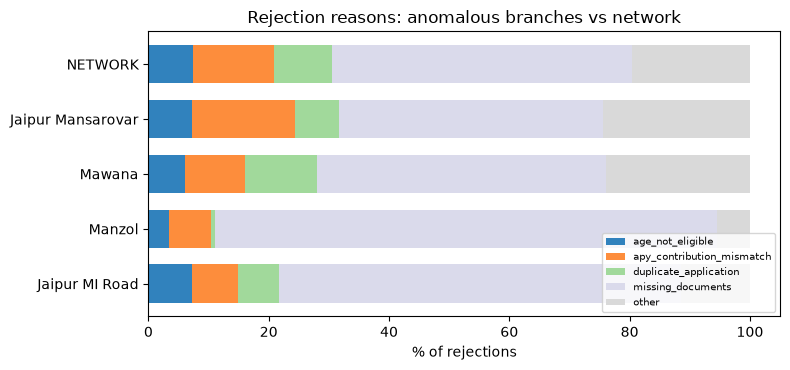

In [7]:
rej = br[br.status == "Rejected"]
mix = pd.crosstab(rej.branch, rej.rejection_reason, normalize="index") * 100
focus = list(sc[sc.anomaly].index) + [b for b in sc.sort_values("approval_rate").index if b not in sc[sc.anomaly].index][:2]
display(mix.loc[focus].round(1))
network_mix = rej.rejection_reason.value_counts(normalize=True) * 100
print("Network-wide mix (%):"); print(network_mix.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = pd.concat([mix.loc[focus], network_mix.to_frame("NETWORK").T]).fillna(0)
plot_df.plot(kind="barh", stacked=True, ax=ax, colormap="tab20c", width=0.7)
ax.set_xlabel("% of rejections"); ax.set_title("Rejection reasons: anomalous branches vs network"); ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.savefig(CHARTS / "rejection_reasons.png", dpi=150); plt.show()

### 4.3 Documents and APY compliance as drivers of rejection

In [8]:
d = a[a.status.isin(["Approved", "Rejected"])]
lift = d.groupby("any_doc_missing").status.apply(lambda s: (s == "Rejected").mean()).rename("rejection_rate")
display(lift.to_frame().round(3))
apy = d[d.apy_compliance.notna()]
display(apy.groupby("apy_compliance").status.agg(n="size", rejection_rate=lambda s: (s == "Rejected").mean()).round(3))

,rejection_rate
any_doc_missing,
False,0.065
True,0.832


,n,rejection_rate
apy_compliance,,
Compliant,3190,0.109
Non-Compliant,234,0.872


### 4.4 Turnaround and backlog by approver

,n,median_days,mean_days,p90_days
approver_id,,,,
2001,3270,2.0,2.54,5.0
2002,4063,2.0,3.05,6.0
2003,2530,5.0,6.60,13.0
2004,1790,2.0,2.03,4.0


bucket,0-7d,8-30d,31-90d,>90d
approver_id,,,,
2001,12,2,7,23
2002,19,4,2,32
2003,29,14,34,181
2004,1,0,2,10


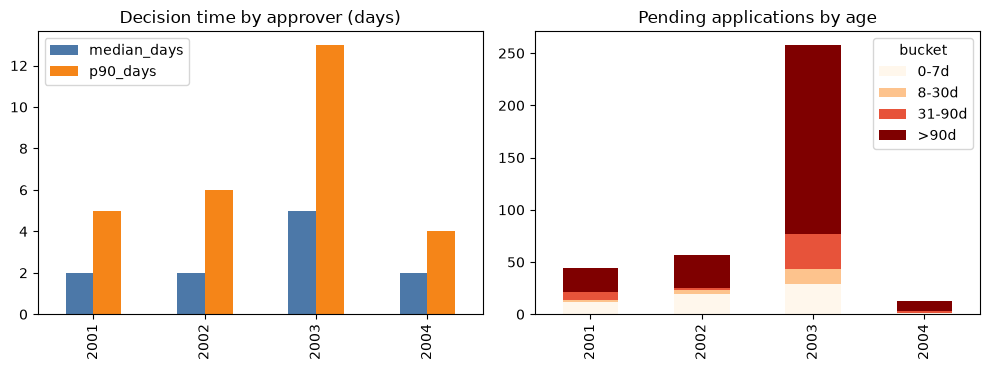

In [9]:
t = a[a.turnaround_days.notna()]
tat = t.groupby("approver_id").turnaround_days.agg(n="size", median_days="median", mean_days="mean", p90_days=lambda s: s.quantile(.9)).round(2)
display(tat)
pend = a[a.status == "Pending"].copy()
pend["bucket"] = pd.cut(pend.pending_age_days, [-1, 7, 30, 90, 10_000], labels=["0-7d", "8-30d", "31-90d", ">90d"])
aging = pd.crosstab(pend.approver_id, pend.bucket)
display(aging)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
tat[["median_days", "p90_days"]].plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"]); axes[0].set_title("Decision time by approver (days)"); axes[0].set_xlabel("")
aging.plot(kind="bar", stacked=True, ax=axes[1], colormap="OrRd"); axes[1].set_title("Pending applications by age"); axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig(CHARTS / "approver_turnaround_backlog.png", dpi=150); plt.show()

### 4.5 Seasonality

scheme,APY,KVP,PMJJBY,PMMY,PMSBY,TOTAL
month,,,,,,
2025-10,291,120,208,140,221,980
2025-11,307,114,186,128,180,915
2025-12,296,125,203,130,203,957
2026-01,302,125,225,133,181,966
2026-02,246,112,182,118,217,875
2026-03,444,170,305,219,276,1414
2026-04,295,123,192,114,196,920
2026-05,271,113,349,119,368,1220
2026-06,274,111,200,136,193,914


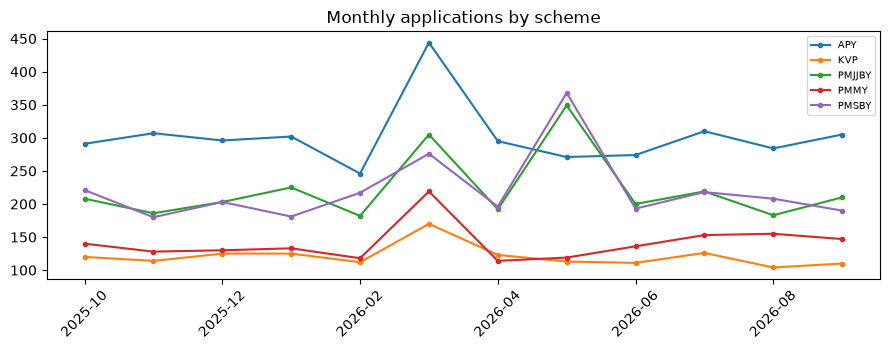

In [10]:
monthly = a.pivot_table(index="month", columns="scheme", values="application_id", aggfunc="count").fillna(0).astype(int)
monthly["TOTAL"] = monthly.sum(axis=1)
display(monthly)
fig, ax = plt.subplots(figsize=(9, 3.6))
monthly.drop(columns="TOTAL").plot(ax=ax, marker="o", ms=3); ax.set_title("Monthly applications by scheme"); ax.set_xlabel(""); ax.legend(fontsize=7)
plt.xticks(rotation=45); plt.tight_layout(); plt.savefig(CHARTS / "monthly_volume.png", dpi=150); plt.show()

## 5. SQL layer
The same questions in SQL (SQLite here; written with `CASE WHEN` and window functions so they port to PostgreSQL). Query 1 is cross-checked against the pandas scorecard.

In [11]:
cols = ["application_id", "scheme", "branch", "region", "approver_id", "status", "submission_date", "decided_date",
        "turnaround_days", "pending_age_days", "rejection_reason", "any_doc_missing"]
sql_df = a[cols].copy()
for c in ("submission_date", "decided_date"): sql_df[c] = sql_df[c].dt.strftime("%Y-%m-%d")
sql_df["any_doc_missing"] = sql_df.any_doc_missing.astype(int)
con = sqlite3.connect(":memory:"); sql_df.to_sql("applications", con, index=False)

Q = {}
Q["q1_branch_scorecard"] = '''
WITH scorecard AS (
  SELECT branch,
         COUNT(*) AS total,
         SUM(CASE WHEN status = 'Approved' THEN 1 ELSE 0 END) AS approved,
         SUM(CASE WHEN status = 'Rejected' THEN 1 ELSE 0 END) AS rejected,
         SUM(CASE WHEN status = 'Pending'  THEN 1 ELSE 0 END) AS pending
  FROM applications
  WHERE branch <> 'Unknown'
  GROUP BY branch)
SELECT branch, total, approved, rejected, pending,
       ROUND(1.0 * approved / NULLIF(approved + rejected, 0), 3) AS approval_rate,
       RANK() OVER (ORDER BY total DESC) AS volume_rank,
       RANK() OVER (ORDER BY 1.0 * approved / NULLIF(approved + rejected, 0) DESC) AS quality_rank
FROM scorecard
ORDER BY volume_rank;'''
Q["q2_monthly_volume_mom"] = '''
WITH m AS (
  SELECT substr(submission_date, 1, 7) AS month, COUNT(*) AS apps
  FROM applications GROUP BY substr(submission_date, 1, 7))
SELECT month, apps,
       LAG(apps) OVER (ORDER BY month) AS prev_month,
       ROUND(100.0 * (apps - LAG(apps) OVER (ORDER BY month)) / LAG(apps) OVER (ORDER BY month), 1) AS mom_pct
FROM m ORDER BY month;'''
Q["q3_pending_aging"] = '''
SELECT approver_id,
       SUM(CASE WHEN pending_age_days <= 7 THEN 1 ELSE 0 END)  AS d0_7,
       SUM(CASE WHEN pending_age_days BETWEEN 8 AND 30 THEN 1 ELSE 0 END) AS d8_30,
       SUM(CASE WHEN pending_age_days BETWEEN 31 AND 90 THEN 1 ELSE 0 END) AS d31_90,
       SUM(CASE WHEN pending_age_days > 90 THEN 1 ELSE 0 END)  AS d90_plus,
       COUNT(*) AS pending_total
FROM applications WHERE status = 'Pending'
GROUP BY approver_id ORDER BY pending_total DESC;'''
Q["q4_approver_turnaround"] = '''
WITH d AS (
  SELECT approver_id, turnaround_days,
         ROW_NUMBER() OVER (PARTITION BY approver_id ORDER BY turnaround_days) AS rn,
         COUNT(*) OVER (PARTITION BY approver_id) AS cnt
  FROM applications WHERE turnaround_days IS NOT NULL)
SELECT approver_id, COUNT(*) AS n,
       ROUND(AVG(turnaround_days), 2) AS avg_days,
       MAX(CASE WHEN rn = (cnt + 1) / 2 THEN turnaround_days END) AS median_days   -- lower median
FROM d GROUP BY approver_id ORDER BY avg_days DESC;'''
Q["q5_rejection_reason_share"] = '''
SELECT branch, rejection_reason, COUNT(*) AS n,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY branch), 1) AS pct_of_branch_rejections
FROM applications
WHERE status = 'Rejected' AND branch <> 'Unknown'
GROUP BY branch, rejection_reason
ORDER BY branch, n DESC;'''

res = {k: pd.read_sql(q, con) for k, q in Q.items()}
for k in ("q1_branch_scorecard", "q2_monthly_volume_mom", "q3_pending_aging", "q4_approver_turnaround"):
    print("\n--", k); display(res[k])
print("\n-- q5 (Manzol only)"); display(res["q5_rejection_reason_share"].query("branch == 'Manzol'"))

# cross-check SQL vs pandas
chk = res["q1_branch_scorecard"].set_index("branch")
assert (chk.total == sc.total.reindex(chk.index)).all() and (chk.rejected == sc.rejected.reindex(chk.index)).all()
print("\nSQL scorecard matches pandas scorecard for all", len(chk), "branches")
_ = Path("../sql/analysis_queries.sql").write_text("\n\n".join(f"-- {k}\n{q.strip()}" for k, q in Q.items()) + "\n")


-- q1_branch_scorecard


,branch,total,approved,rejected,pending,approval_rate,volume_rank,quality_rank
0,Jaipur MI Road,1323,1040,263,20,0.798,1,19
1,Meerut City,883,796,78,9,0.911,2,2
2,Delhi Karol Bagh,784,631,82,71,0.885,3,14
3,Noida Sector 18,775,695,73,7,0.905,4,3
4,Jaipur Vaishali Nagar,739,659,70,10,0.904,5,4
5,Delhi Lajpat Nagar,692,566,66,60,0.896,6,8
6,Ghaziabad Nehru Nagar,648,577,66,5,0.897,7,7
7,Jaipur Mansarovar,638,549,82,7,0.870,8,17
8,Hapur,579,504,63,12,0.889,9,12
9,Delhi Rohini,577,448,63,66,0.877,10,15



-- q2_monthly_volume_mom


,month,apps,prev_month,mom_pct
0,2025-10,980,NaN,NaN
1,2025-11,915,980.0,-6.6
2,2025-12,957,915.0,4.6
3,2026-01,966,957.0,0.9
4,2026-02,875,966.0,-9.4
5,2026-03,1414,875.0,61.6
6,2026-04,920,1414.0,-34.9
7,2026-05,1220,920.0,32.6
8,2026-06,914,1220.0,-25.1
9,2026-07,1026,914.0,12.3



-- q3_pending_aging


...


-- q4_approver_turnaround


,approver_id,n,avg_days,median_days
0,2003,2530,6.60,5.0
1,2002,4063,3.05,2.0
2,2001,3270,2.54,2.0
3,2004,1790,2.03,2.0



-- q5 (Manzol only)


,branch,rejection_reason,n,pct_of_branch_rejections
69,Manzol,missing_documents,120,83.3
70,Manzol,apy_contribution_mismatch,10,6.9
71,Manzol,other,8,5.6
72,Manzol,age_not_eligible,5,3.5
73,Manzol,duplicate_application,1,0.7



SQL scorecard matches pandas scorecard for all 20 branches


## 6. Export clean tables (for Tableau Public)

In [12]:
a.to_csv(CLEAN / "applications_clean.csv", index=False)
sc.reset_index().to_csv(CLEAN / "branch_scorecard.csv", index=False)
monthly.reset_index().to_csv(CLEAN / "monthly_volume.csv", index=False)
tat.reset_index().to_csv(CLEAN / "approver_turnaround.csv", index=False)
aging.reset_index().to_csv(CLEAN / "pending_aging.csv", index=False)
print(sorted(p.name for p in CLEAN.iterdir()))

['applications_clean.csv', 'approver_turnaround.csv', 'branch_scorecard.csv', 'cleaning_log.csv', 'monthly_volume.csv', 'pending_aging.csv']


## 7. Findings (computed from the data above)

In [13]:
from IPython.display import Markdown
top_vol = sc.sort_values("volume_rank").iloc[0]; best = sc.sort_values("quality_rank").iloc[0]
anoms = sc[sc.anomaly].sort_values("z_score", ascending=False)
slow = tat.median_days.idxmax(); others_median = t[t.approver_id != slow].turnaround_days.median()
stale = pend[pend.is_stale_pending].groupby("approver_id").size().sort_values(ascending=False)
mar = monthly.loc["2026-03", "TOTAL"]; neigh = monthly.loc[["2026-02", "2026-04"], "TOTAL"].mean()
may = monthly.loc["2026-05", ["PMJJBY", "PMSBY"]].sum(); may_n = monthly.loc[["2026-04", "2026-06"], ["PMJJBY", "PMSBY"]].sum(axis=1).mean()
manz_reason = mix.loc[anoms.index[0]].idxmax() if len(anoms) else "n/a"
txt = f'''
1. **Volume and quality diverge.** {top_vol.name} submits the most applications ({int(top_vol.total):,}) yet ranks #{int(top_vol.quality_rank)} of {len(sc)} on approval rate
   ({top_vol.approval_rate:.1%}). {best.name} is #1 on quality ({best.approval_rate:.1%}) with only {int(best.total):,} applications, so a count-only ranking rewards the wrong branches.
2. **Anomalous branches:** {", ".join(f"{b} ({r.rejection_rate:.1%} rejected, z={r.z_score:.1f})" for b, r in anoms.iterrows()) or "none"} against a network rate of {p0:.1%};
   the dominant reason is **{manz_reason.replace("_", " ")}**.
3. **Missing documents drive rejections:** {lift[True]:.1%} rejection when any document is missing vs {lift[False]:.1%} otherwise.
   APY applications with non-compliant contributions are rejected {apy.groupby("apy_compliance").status.apply(lambda s: (s=="Rejected").mean())["Non-Compliant"]:.1%} of the time.
4. **Approver {slow} is the bottleneck:** median {tat.median_days[slow]:.0f} days vs {others_median:.0f} for the other approvers, and holds {int(stale.get(slow, 0))} of {int(stale.sum())} pending applications older than 30 days.
5. **Seasonality:** March volume is {mar / neigh - 1:+.0%} vs the surrounding months; PMJJBY+PMSBY volume in May is {may / may_n - 1:+.0%}.
'''
Markdown(txt)


1. **Volume and quality diverge.** Jaipur MI Road submits the most applications (1,323) yet ranks #19 of 20 on approval rate
   (79.8%). Gurugram Sector 14 is #1 on quality (92.1%) with only 303 applications, so a count-only ranking rewards the wrong branches.
2. **Anomalous branches:** Manzol (29.6% rejected, z=11.3), Jaipur MI Road (20.2% rejected, z=8.2) against a network rate of 12.6%;
   the dominant reason is **missing documents**.
3. **Missing documents drive rejections:** 83.2% rejection when any document is missing vs 6.5% otherwise.
   APY applications with non-compliant contributions are rejected 87.2% of the time.
4. **Approver 2003 is the bottleneck:** median 5 days vs 2 for the other approvers, and holds 215 of 291 pending applications older than 30 days.
5. **Seasonality:** March volume is +58% vs the surrounding months; PMJJBY+PMSBY volume in May is +84%.


### Caveats
* Data is synthetic and the patterns above were planted; the analysis recovering them shows the pipeline works, not that real branches behave this way.
* `decided_date` and `approver_id` do not exist in the current Vartalaap schema. Adding them is the next product change that would make this analysis possible on real data.
* Rejection-reason categories come from keyword rules on free text; agreement with the true cause is reported in Section 3. It is very high because the synthetic remarks come from a small template set; real free text would be messier.
* Rule-based amount checks have limited recall (Section 3): some typos are plausible values and cannot be caught without a reference.